# Reversal signals: ML extension

**The walk-forward ML version kept for further testing, alongside one fixed candidate**

One issue with the original strategy is that persistent losers are not distinguished from the economic pressure hypothesis. XGBoost and Ridge are used to forecast the return of each trade proposed by the reversal rule. If that forecast is negative, leave in cash.

Fixed configuration 28 has a slightly higher historical Sharpe with XGBoost, but a lower total return. When both approaches select configurations through time, the unfiltered walk-forward outperforms the XGBoost version on both returns and Sharpe, but this is only due to a difference in performance during the post-COVID 19 2020-2021 economic resurgence.

This notebook preserves the key results and details, while the [original notebook](archive/reversal_signals_ml_research_2026-09-28.ipynb) contains all nitty-gritty details.

### Imports and setup

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display
%matplotlib inline

HERE = Path.cwd().resolve()
PROJECT = next(path for base in (HERE, *HERE.parents)
               for path in (base, base / "uk_portfolio/reversal_signals", base / "trading_portfolio/uk_portfolio/reversal_signals")
               if (path / "src/reversal_ml_research.py").is_file())
if str(PROJECT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT / "src"))

import reversal_ml_research as research
import reversal_ml_reporting as reporting

cache = research.ResearchCache(PROJECT)

## Data and economic hypothesis

Keep the same universe and eligibility rules as the previous notebook.

A recent price fall can reflect temporary selling pressure mentioned above, or just constant repricing of the asset. Past returns, volatility, relative volume and the movement of other eligible shares could distinguish these situations. The model forecasts each proposed asset's return over the holding period, and retains its allocation only when that forecast is positive. Rejected allocations remain in cash.

In [2]:
inputs = research.prepare_inputs(PROJECT)
display(inputs["periods"])
display(inputs["grid"].join(inputs["coverage"]).round(3))

,first_session,last_session,sessions
period,,,
Development,2017-01-03,2019-12-31,758
Assessment,2020-01-02,2021-12-31,507
Historical extension,2022-01-04,2025-12-31,1008


,formation_sessions,holding_sessions,is_baseline,rebalance_sessions,top_frac,candidate_trades,complete_features,observed_outcomes
configuration_id,,,,,,,,
0,1,1,False,1,0.1,29950,29950,29950
1,1,3,False,3,0.1,9976,9976,9975
2,1,5,False,5,0.1,5977,5977,5977
3,1,1,False,1,0.2,58379,58379,58378
4,1,3,False,3,0.2,19438,19438,19435
5,1,5,False,5,0.2,11650,11650,11649
6,1,1,False,1,0.3,86369,86369,86365
7,1,3,False,3,0.3,28704,28704,28700
8,1,5,False,5,0.3,17293,17293,17292


## Model and trading rules

The following features are trained on: raw reversal score, 1, 20 trading day returns, 20 trading day volatility, relative volume and the eligible universe's daily return. Only outcomes observable before fitting are used as training data. Signals form and execute in the same way as previously.

Ridge uses standardisation and alpha 1. XGBoost uses 100 depth two trees, learning rate 0.05, minimum child weight 50 and L2 regularisation 10. Settings and the zero forecast threshold remain fixed.

Forecasts target gross open-to-open returns including dividends. Positive predictions need not cover costs, just be strictly positive.

Costs remain 10 bp per side. This may be too low, but is set to undergo further testing when more information is known. The benchmark matches target exposure without selecting stocks. Continuous portfolios carry positions across refits, despite the potential changing of configurations

Average stock exposure is the arithmetic mean of daily closing stock value divided by portfolio equity, expressed as a percentage. It includes days held entirely in cash and excludes each simulation’s initial cash row. Linked annual comparisons weight every trading session equally. The remainder is cash; target-matched controls can have slightly different realised exposure as their holdings change in value.


## Annual development: 2017–2019

A model is fitted for each parameter configuration using the previous year of data. Each year begins with £10,000, with no interest, and does not execute trades which cross year end boundaries.

Start by inspecting the 2019 prediction error against each configurations training mean forecast. Higher MSE skills means lower squared prediction error. Then pool the three years' daily net portfolio returns, and compare Sharpe ratios. 

In [3]:
development = research.run_development(inputs, cache)
display(reporting.prediction_skill_summary(development).round(4))
display(development["statistics"]["net_sharpe"].unstack("variant")
        [list(research.WEIGHT_COLUMNS)].round(3))

Rebuilding development from frozen inputs.


,configurations,positive_MSE_skill,median_MSE_skill
Ridge,36.0,10.0,-0.0059
XGBoost,36.0,13.0,-0.0031


variant,Unfiltered,Ridge,XGBoost,Ridge control,XGBoost control
configuration_id,,,,,
0,-1.371,0.465,-0.192,-1.236,-0.914
1,0.639,0.669,0.643,0.614,1.018
2,-0.349,-0.500,0.456,-0.358,-0.151
3,-2.323,-0.292,-0.314,-2.063,-1.892
4,0.134,0.480,0.592,0.252,0.540
5,-0.192,-0.054,0.240,-0.115,-0.022
6,-3.119,-0.765,-0.353,-2.749,-2.281
7,-0.103,-0.042,0.585,-0.034,0.248
8,-0.153,-0.115,-0.117,-0.150,-0.132


Looking at the development results above, XGBoost 28, 15 and 12 are retained, alongside the best Ridge approach, 28.

### Configuration selection

Only 10/36 Ridge, and 13/36 XGBoost improve the training mean forecast. A model can still change porfolio performance through selection and exposure, menaing forecast error and portfolio returns are two seperate assessments.

Looking at the development results above, XGBoost 28, 15 and 12 are retained, alongside the best Ridge approach, 28.

In [4]:
finalists, assessment_plan, assessment_cases = research.select_finalists(development, inputs["grid"])
display(assessment_plan.round(3))

,variant,configuration_id,role,development_net_sharpe,formation_sessions,top_frac,holding_sessions
0,Unfiltered,9,primary,1.694,3,0.1,1
1,Ridge,28,primary,1.898,10,0.1,3
2,XGBoost,15,primary,1.941,3,0.3,1
3,XGBoost,12,sensitivity,1.912,3,0.2,1
4,XGBoost,28,sensitivity,1.929,10,0.1,3


## Assessment: 2020–2021

Keep the above configurations, model settings fixed, and refit at the start of each year based on previous outcomes with the same annual reset, zero interest assumptions.

In [5]:
assessment = research.run_assessment(inputs, development, cache)
display(reporting.annual_comparison(assessment).round(2))

Rebuilding assessment from frozen inputs.


year                                   2020                              2021  \
                                 Return (%) Avg stock exposure (%) Return (%)   
configuration_id variant                                                        
9                Unfiltered           52.62                  56.75      24.71   
12               Unfiltered           36.95                  97.40      -1.72   
                 XGBoost              51.10                  49.12      35.97   
                 XGBoost control      21.34                  49.07      12.87   
15               Unfiltered            9.36                  95.66     -13.03   
                 XGBoost              28.54                  47.71      24.93   
                 XGBoost control       9.30                  47.68       5.14   
28               Ridge                29.59                  42.53      80.64   
                 Ridge control        32.29                  42.59      60.59   
                 Unfiltered           89.34                  56.36      82.84   
                 XGBoost              38.98                  44.67      78.45   
                 XGBoost control      43.10                  44.70      73.90   

year                                                     
                                 Avg stock exposure (%)  
configuration_id variant                                 
9                Unfiltered                       86.10  
12               Unfiltered                       98.92  
                 XGBoost                          44.57  
                 XGBoost control                  44.53  
15               Unfiltered                       98.26  
                 XGBoost                          40.21  
                 XGBoost control                  40.14  
28               Ridge                            70.43  
                 Ridge control                    70.39  
                 Unfiltered                       85.64  
                 XGBoost                          73.97  
                 XGBoost control                  73.98

XGBoost improves configurations 12, 15 relative to their unfiltered versions in both years. Configuration 28 has the opposite effect in both years, and also has significantly less exposure. Its 2020 return is 89.34%, compared with 38.98% for XGBoost. However, it also has the best performance of all XGBoost approaches across the years, and is kept for further testing.

## Historical extension: 2022–2025

Continue with configuration 28, and the same annual refit approach as previously. Configuration 12 is kept as a sensitivity.

In [6]:
continuation = research.run_continuation(inputs, cache)
display(reporting.annual_comparison(continuation).round(2))
display(continuation["summary"]["net_sharpe"].unstack("year").round(2))

Rebuilding continuation from frozen inputs.


year                                   2022                              2023  \
                                 Return (%) Avg stock exposure (%) Return (%)   
configuration_id variant                                                        
12               Unfiltered          -53.38                  98.51     -34.79   
                 XGBoost             -17.76                  57.93       2.11   
                 XGBoost control     -26.37                  57.84     -10.81   
28               Unfiltered           -7.28                  67.43      17.53   
                 XGBoost              -6.22                  61.03      19.32   
                 XGBoost control      -6.43                  61.07      17.28   

year                                                          2024  \
                                 Avg stock exposure (%) Return (%)   
configuration_id variant                                             
12               Unfiltered                       97.88     -26.27   
                 XGBoost                          39.98      23.92   
                 XGBoost control                  39.89      -0.61   
28               Unfiltered                       58.95       9.08   
                 XGBoost                          51.68      13.86   
                 XGBoost control                  51.71       7.44   

year                                                          2025  \
                                 Avg stock exposure (%) Return (%)   
configuration_id variant                                             
12               Unfiltered                       98.15     -35.59   
                 XGBoost                          29.41       7.31   
                 XGBoost control                  29.29      -8.03   
28               Unfiltered                       65.44      34.16   
                 XGBoost                          60.24      24.62   
                 XGBoost control                  60.21      30.94   

year                                                     
                                 Avg stock exposure (%)  
configuration_id variant                                 
12               Unfiltered                       98.30  
                 XGBoost                          33.84  
                 XGBoost control                  33.75  
28               Unfiltered                       72.48  
                 XGBoost                          64.81  
                 XGBoost control                  64.74

year                              2022  2023  2024  2025
configuration_id variant                                
12               Unfiltered      -2.70 -2.25 -1.61 -2.33
                 XGBoost         -0.88  0.23  2.12  0.60
                 XGBoost control -1.63 -1.17 -0.06 -0.83
28               Unfiltered      -0.19  1.04  0.63  1.52
                 XGBoost         -0.17  1.21  0.95  1.22
                 XGBoost control -0.18  1.12  0.57  1.53

Configuration 12 performs quite poorly over this period, but its XGBoost version does improve it significantly, but doesn't provide evidence to prefer it to configuration 28. XGBoost improves returns over 2022-2024, but loses in 2025. Compounded 2022–2025 returns are 59.48% unfiltered and 58.78% with XGBoost.

### Configuration 28 across the full history

Link daily returns from the separate annual simulations to show the path from 2017 to 2025. This is an index starting at 100, not a continuous account carried through year-end. It retains the annual trading gaps, model refits and zero cash interest.

XGBoost 28 is kept constant across the whole time, and is compared with its unfiltered version. Results include modelled transaction fees, but no interest on cash holdings.  It retains the annual trading gaps and model refits over previous, seen, evaluated-on data.

,linked_return_pct,net_sharpe,annual_volatility_pct,max_drawdown_pct,mean_stock_exposure_pct
Unfiltered,874.390,1.337,20.453,-30.793,59.216
XGBoost,672.053,1.357,17.881,-29.373,49.858
XGBoost control,536.303,1.273,17.303,-29.661,49.853


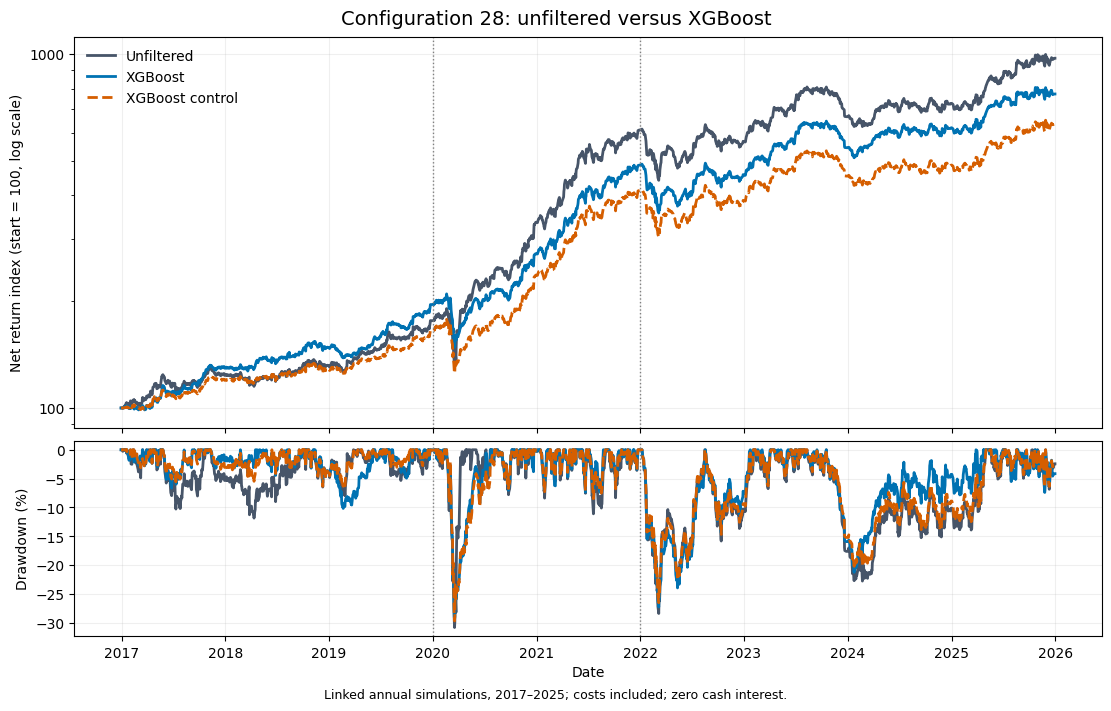

In [7]:
fixed_28 = research.link_fixed_configuration(
    [development, assessment, continuation], inputs["schedule"], configuration_id=28)
display(reporting.fixed_comparison_summary(
    fixed_28, [development, assessment, continuation]).round(3))
figure, axes = reporting.plot_fixed_comparison(fixed_28)

Unfiltered configuration 28 returns 874.39%, compared with 672.05% for XGBoost. Filtering reduces annualised volatility from 20.45% to 17.88%, with a small Sharpe increase from 1.337 to 1.357. This is mixed, the unfiltered has slightly lower Sharpe, but higher total returns.  No statistical test here establishes that the small Sharpe difference is reliable, although looking at the 2020-2021 performance, a lot of the gap seems to come from the post-COVID 19 economic rebound.

## Continuous walk-forward comparison

Now do expanding walk-forward evaluation of both unfiltered and XGBoost filtered portfolio. Both begin with £10,000, and are continuous across year boundaries 

First accumulate 504 trading days to train the models, then 504 trading days of forward-predicted candidate returns to rank configurations. Both selectors therefore start trading on 25/03/2019. All configurations are tested. Both approaches use configurations selected every 63 trading days using expanding daily mean net excess over their respective benchmarks. Non-positive best excess means no new entries.

The universe ranking system is unchanged, using uncapped weights and no interest on cash, but final portfolios can be capped and do include 3.8% fixed AER on cash.

In [8]:
continuous = research.run_continuous(inputs, cache)
display(continuous["choice_comparison"])
display(reporting.continuous_comparison_summary(continuous).round(2))

Rebuilding walk_forward from frozen inputs.


,selection_date,test_start,test_end,Unfiltered_configuration,XGBoost_configuration
fold,,,,,
8,2019-03-22,2019-03-25,2019-06-25,9,9
9,2019-06-25,2019-06-26,2019-09-23,9,9
10,2019-09-23,2019-09-24,2019-12-19,9,9
11,2019-12-19,2019-12-20,2020-03-20,9,9
12,2020-03-20,2020-03-23,2020-06-23,27,9
13,2020-06-23,2020-06-24,2020-09-21,27,9
14,2020-09-21,2020-09-22,2020-12-17,27,9
15,2020-12-17,2020-12-18,2021-03-19,27,9
16,2021-03-19,2021-03-22,2021-06-22,27,9


ending_equity_gbp  net_total_return_pct  \
variant    portfolio                                            
Unfiltered Strategy            58403.75                484.04   
           Benchmark           13253.95                 32.54   
XGBoost    Strategy            43118.21                331.18   
           Benchmark           12251.60                 22.52   

                      max_drawdown_pct  total_cost_gbp  cash_interest_gbp  \
variant    portfolio                                                        
Unfiltered Strategy             -32.02        26890.63            2752.82   
           Benchmark            -28.15          613.84             985.82   
XGBoost    Strategy             -29.31        16397.52            2505.45   
           Benchmark            -25.68         1508.21            1199.53   

                      mean_stock_exposure_pct  net_sharpe  
variant    portfolio                                       
Unfiltered Strategy                     65.73        1.30  
           Benchmark                    64.18        0.44  
XGBoost    Strategy                     56.74        1.17  
           Benchmark                    55.49        0.36

The raw selector moves from configuration 9 to 27. The ML selector moves from 9 to 27 and then 28. The raw strategy finishes at £58,403.75, against £43,118.21 for ML. Maximum drawdown for the ML filter improves somewhat, from −32.02% to −29.31%. The filter also limits exposure, which could explain some of the difference in returns.

Unfiltered                                      XGBoost  \
     Return (%) Avg stock exposure (%) Net Sharpe Return (%)   
year                                                           
2019       8.03                  45.51       0.78      16.92   
2020      97.95                  57.14       2.28      60.06   
2021     120.50                  86.55       3.60      45.60   
2022     -22.64                  68.16      -0.98     -17.16   
2023      27.27                  59.69       1.48      28.65   
2024       6.69                  65.98       0.47      16.02   
2025      17.91                  72.45       0.92      27.98   

                                        
     Avg stock exposure (%) Net Sharpe  
year                                    
2019                  35.61       1.61  
2020                  43.40       1.84  
2021                  75.16       1.78  
2022                  62.14      -0.70  
2023                  53.01       1.68  
2024                  59.17       1.08  
2025                  63.91       1.37

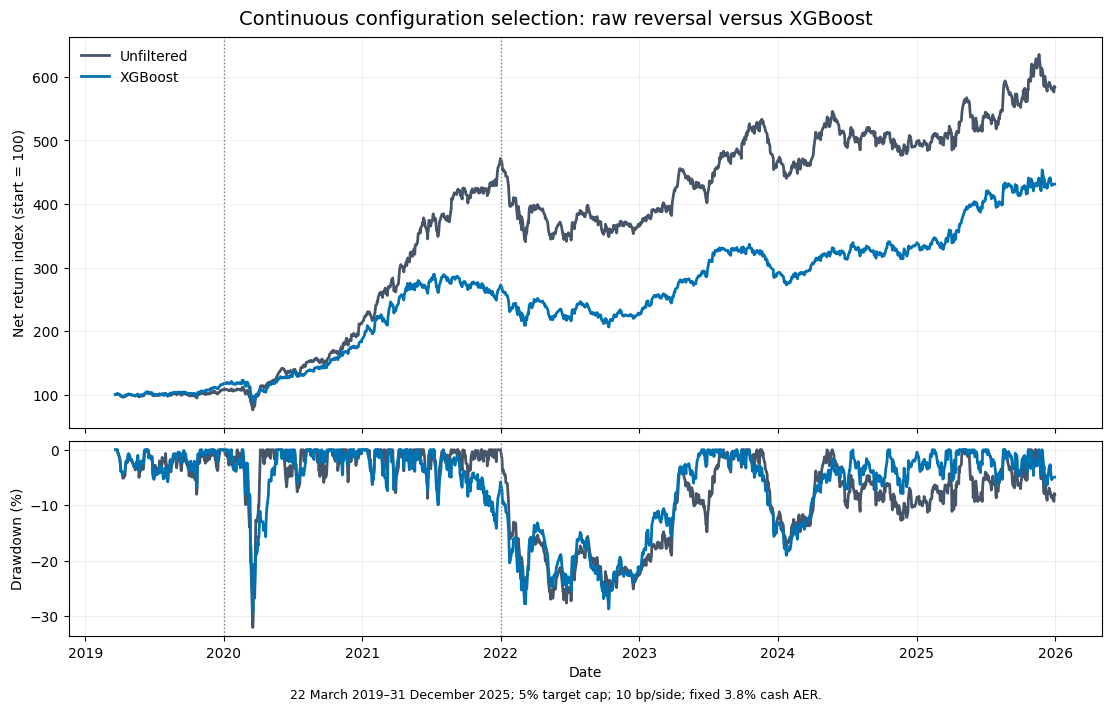

In [9]:
display(reporting.continuous_annual_comparison(continuous).round(2))
fig, ax = reporting.plot_continuous_comparison(continuous)

The filter approach improves the strategy in every year outside of the 2020-2021 post-COVID 19 economic rebound. Changes are both filtering and configuration selection, so does not isolate the filter's contribution alone. The Sharpe of the Filter is also better each year apart from 2020-2021, with that period making the difference of the total Sharpe ratio too. The filter did not perform badly in this period, but the unfiltered performed outrageously good, with Sharpe ratio's of 2.28 and 3.60 in 2020 and 2021 respectively.

## Cost sensitivity

End by testing the ML strategy's sensitivity to transaction fees by testing at 0, 10, 20, 30bp per side. First, for the walk-forward approach, secondly for configuration 28

In [16]:
continuous_costs = research.continuous_cost_sensitivity(inputs, continuous)
display(continuous_costs[["ending_equity_gbp", "net_total_return_pct", "max_drawdown_pct", "total_cost_gbp", "net_sharpe", "mean_daily_net_excess_bps"]].round(2))

ending_equity_gbp  \
cost_per_side_bps variant    portfolio                      
0.0               Unfiltered Benchmark           13912.60   
                             Strategy           125586.00   
                  XGBoost    Benchmark           13936.93   
                             Strategy            87573.95   
10.0              Unfiltered Benchmark           13253.95   
                             Strategy            58403.75   
                  XGBoost    Benchmark           12251.60   
                             Strategy            43118.21   
20.0              Unfiltered Benchmark           12627.72   
                             Strategy            27213.70   
                  XGBoost    Benchmark           10773.48   
                             Strategy            21244.30   
30.0              Unfiltered Benchmark           12032.27   
                             Strategy            12715.83   
                  XGBoost    Benchmark            9476.83   
                             Strategy            10477.08   

                                        net_total_return_pct  \
cost_per_side_bps variant    portfolio                         
0.0               Unfiltered Benchmark                 39.13   
                             Strategy                1155.86   
                  XGBoost    Benchmark                 39.37   
                             Strategy                 775.74   
10.0              Unfiltered Benchmark                 32.54   
                             Strategy                 484.04   
                  XGBoost    Benchmark                 22.52   
                             Strategy                 331.18   
20.0              Unfiltered Benchmark                 26.28   
                             Strategy                 172.14   
                  XGBoost    Benchmark                  7.73   
                             Strategy                 112.44   
30.0              Unfiltered Benchmark                 20.32   
                             Strategy                  27.16   
                  XGBoost    Benchmark                 -5.23   
                             Strategy                   4.77   

                                        max_drawdown_pct  total_cost_gbp  \
cost_per_side_bps variant    portfolio                                     
0.0               Unfiltered Benchmark            -28.10            0.00   
                             Strategy             -31.25            0.00   
                  XGBoost    Benchmark            -25.56            0.00   
                             Strategy             -28.59            0.00   
10.0              Unfiltered Benchmark            -28.15          613.84   
                             Strategy             -32.02        26890.63   
                  XGBoost    Benchmark            -25.68         1508.21   
                             Strategy             -29.31        16397.52   
20.0              Unfiltered Benchmark            -28.32         1196.32   
                             Strategy             -33.54        33936.12   
                  XGBoost    Benchmark            -28.75         2818.51   
                             Strategy             -40.58        21862.21   
30.0              Unfiltered Benchmark            -29.97         1749.04   
                             Strategy             -47.02        33415.59   
                  XGBoost    Benchmark            -32.53         3955.97   
                             Strategy             -52.60        22706.03   

                                        net_sharpe  mean_daily_net_excess_bps  
cost_per_side_bps variant    portfolio                                         
0.0               Unfiltered Benchmark        0.50                        NaN  
                             Strategy         1.81                      13.59  
                  XGBoost    Benchmark        0.55                        NaN  
                   

In [17]:
fixed_costs = research.fixed_cost_sensitivity(inputs, fixed_28)
display(fixed_costs.round(2))

linked_return_pct  net_sharpe  \
cost_per_side_bps variant                                          
0.0               Unfiltered                 1469.09        1.60   
                  XGBoost                    1118.11        1.64   
                  XGBoost control             872.21        1.54   
10.0              Unfiltered                  874.39        1.34   
                  XGBoost                     672.05        1.36   
                  XGBoost control             536.30        1.27   
20.0              Unfiltered                  505.17        1.08   
                  XGBoost                     389.41        1.07   
                  XGBoost control             316.52        1.00   
30.0              Unfiltered                  275.91        0.82   
                  XGBoost                     210.29        0.79   
                  XGBoost control             172.69        0.73   

                                   annual_volatility_pct  max_drawdown_pct  \
cost_per_side_bps variant                                                    
0.0               Unfiltered                       20.45            -30.53   
                  XGBoost                          17.88            -29.11   
                  XGBoost control                  17.31            -29.41   
10.0              Unfiltered                       20.45            -30.79   
                  XGBoost                          17.88            -29.37   
                  XGBoost control                  17.30            -29.66   
20.0              Unfiltered                       20.47            -31.06   
                  XGBoost                          17.90            -29.63   
                  XGBoost control                  17.31            -29.91   
30.0              Unfiltered                       20.50            -31.32   
                  XGBoost                          17.92            -29.89   
                  XGBoost control                  17.34            -30.16   

                                   return_2022_2025_pct  
cost_per_side_bps variant                                
0.0               Unfiltered                     101.23  
                  XGBoost                         99.53  
                  XGBoost control                 91.80  
10.0              Unfiltered                      59.48  
                  XGBoost                         58.78  
                  XGBoost control                 54.37  
20.0              Unfiltered                      26.41  
                  XGBoost                         26.36  
                  XGBoost control                 24.26  
30.0              Unfiltered                       0.20  
                  XGBoost                          0.56  
                  XGBoost control                  0.03

In the adaptive walk-forward, adding 10bp of costs to each side approximately reduces the unfiltered returns by 4.2bp per day, and the XGBoost returns by ~3.4bp per day, implying that XGBoost performs slightly better, but both fall to roughly zero net returns at ~33bp per side.

The Sharpe advantage in configuration 28 has vanishes by 20bp, and has reversed by 30bp, although at similarly small margins. Net returns are ~0 at 30bp per side for this approach over the 2022-2025 period.

## Conclusion

- The adaptive ML approach gives up substantial returns overall, primarily in 2020-2021. It is kept for research purposes for the portfolio due to its general outperformance outside of unprecedented political circumstances.
- Fixed configuration 28 also remains a research candidate. These heavily overlap, but the slight differences make both worthy of further testing. Looking forward, they are the same approach, unless the adaptive walk-forward decides to swap configurations. 
- Configuration 28's slightly higher historical Sharpe and lower volatility do not demonstrate a dependable ML advantage. Configuration selection involved repeated inspection of historical periods.
- Walk-forward strategies fall to zero net returns at ~33bp transaction costs per side, with fixed configuration 28 falling to net zero at ~30bp per side. Both approaches are viable at 10bp, marginal at 20bp and roughly zero at 30bp.
- Universe includes survivorship bias due to delisting of stocks. Neither strategy has a demonstrated statistical edge.